# Loss Stability and Consistency Training

This notebook assumes the encode → Koopman step → decode workflow from
[`01_synthetic_graph.ipynb`](01_synthetic_graph.ipynb); here the focus is loss terms
and soft operator-stability options that shape that loop.

It compares **training objectives** for `GraphKoopmanModel` on the same synthetic
graph sequence. KoopmanGraph supports several loss terms beyond one-step
reconstruction (row-state convention $z_{t+1}\approx z_t K^\top$):

- **Forward consistency** — $\mathrm{MSE}(z_t K^\top,\, z_{t+1})$ so encoded states
  evolve linearly under $K$.
- **Backward consistency** — recover $z_t$ from $z_{t+1}$ via the Moore–Penrose
  pseudoinverse, $z_{t+1}(K^\dagger)^\top$ (after removing control contributions
  when present).
- **Rollout loss** — multi-step autoregressive predictions should match the data.
- **Eigenvalue hinge** (optional) — $\mathrm{mean}(\max(|\lambda|-1,0)^2)$ penalizes
  modes outside the unit circle.
- **Loss schedules** — ramp consistency weights over early epochs for stability.

We train three models with identical initialization and compare one-step vs multi-step
forecast error.


## Method: loss configurations

| Label | Objective |
|-------|-----------|
| `recon_only` | One-step reconstruction MSE only |
| `forward_rollout` | Reconstruction + forward consistency + rollout (common tutorial default) |
| `full_schedule` | Same as above, plus **backward** consistency with a **linear weight ramp** |

All models share the same data, architecture, random seed, and rollout horizon during
training. Soft operator constraints (ODO + eigenvalue hinge) appear later; hard
structural modes (`schur` / `dissipative` / `lyapunov`) are covered in
[`11_long_horizon_stability.ipynb`](11_long_horizon_stability.ipynb).


## Setup

Imports, shared synthetic data, and notebook hyperparameters.


In [1]:
import warnings

from tqdm.std import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

import os
import random

import matplotlib

if os.environ.get("PYTEST_CURRENT_TEST"):
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch_geometric.data import Data

try:
    from IPython import get_ipython

    if get_ipython() is not None and not os.environ.get("PYTEST_CURRENT_TEST"):
        get_ipython().run_line_magic("matplotlib", "inline")
except (ImportError, NameError):
    pass

from koopman_graph import GNNDecoder, GNNEncoder, GraphKoopmanModel, GraphSnapshotSequence
from koopman_graph.datasets import SyntheticDynamicGraphBenchmark
from koopman_graph.training import LossWeights, linear_ramp_loss_weights

# Shared path-graph sequence and notebook hyperparameters (defined once here).
MODEL_SEED = 0
random.seed(MODEL_SEED)
np.random.seed(MODEL_SEED)
torch.manual_seed(MODEL_SEED)

data_sequence = SyntheticDynamicGraphBenchmark.generate(
    num_nodes=20,
    num_timesteps=20 if os.environ.get("PYTEST_CURRENT_TEST") else 35,
    in_channels=3,
    topology="path",
    seed=42,
    initial_state="ones",
    decay_rate=0.97,
    diffusion_rate=0.25,
    noise_std=0.02,
)

IN_CHANNELS = data_sequence.in_channels
HIDDEN = 48
LATENT = 48
ROLLOUT_HORIZON = 10
EPOCHS = 25 if os.environ.get("PYTEST_CURRENT_TEST") else 100
STABILITY_EPOCHS = 25 if os.environ.get("PYTEST_CURRENT_TEST") else 60

print(f"Snapshots: {data_sequence.num_timesteps}")
print(f"Nodes: {data_sequence.num_nodes}")


Snapshots: 35
Nodes: 20


## Helper functions

Notebook-local helpers used below. Hyperparameters and `data_sequence` come from the setup cell above.


In [2]:
def build_model() -> GraphKoopmanModel:
    encoder = GNNEncoder(IN_CHANNELS, HIDDEN, LATENT)
    decoder = GNNDecoder(LATENT, HIDDEN, IN_CHANNELS)
    return GraphKoopmanModel(
        encoder=encoder,
        decoder=decoder,
        latent_dim=LATENT,
        time_step=0.1,
    )

def train_variant(
    name: str,
    *,
    loss_weights: LossWeights | None = None,
    loss_weight_schedule=None,
) -> tuple[GraphKoopmanModel, list[float]]:
    torch.manual_seed(MODEL_SEED)
    model = build_model()
    history = model.fit(
        data_sequence,
        epochs=EPOCHS,
        lr=1e-3,
        loss_weights=loss_weights,
        loss_weight_schedule=loss_weight_schedule,
        rollout_horizon=ROLLOUT_HORIZON,
    )
    print(f"{name}: final loss={history.loss[-1]:.6f}, epochs={history.epochs}")
    return model, history.loss

def one_step_mse(model: GraphKoopmanModel, sequence: GraphSnapshotSequence) -> float:
    model.eval()
    errors: list[torch.Tensor] = []
    with torch.no_grad():
        for left, right in zip(sequence[:-1], sequence[1:], strict=True):
            pred = model(left)
            errors.append(torch.mean((pred - right.x) ** 2))
    return torch.stack(errors).mean().item()

def rollout_mse(
    model: GraphKoopmanModel,
    sequence: GraphSnapshotSequence,
    *,
    start_idx: int = 0,
    steps: int,
) -> float:
    model.eval()
    with torch.no_grad():
        preds = model.predict(sequence[start_idx], steps=steps)
    truth = sequence[start_idx + 1 : start_idx + 1 + steps]
    per_step = [torch.mean((p.x - t.x) ** 2) for p, t in zip(preds, truth, strict=True)]
    return torch.stack(per_step).mean().item()

def latent_rollout_norm(model: GraphKoopmanModel, initial: Data, steps: int) -> float:
    model.eval()
    with torch.no_grad():
        z = model.encoder(initial, initial.edge_index)
        for _ in range(steps):
            z = model.koopman(z)
        return float(z.norm().item())


## Train

Training curves across loss configurations.

These curves show **optimization progress**, not a fair ranking of objectives: each
config minimizes a different weighted sum (reconstruction-only is a single term; the
others add consistency and rollout penalties), so absolute loss values are not
cross-comparable.


In [3]:
schedule = linear_ramp_loss_weights(
    start=LossWeights(reconstruction=1.0, forward=0.2, backward=0.0, rollout=0.3),
    end=LossWeights(reconstruction=1.0, forward=1.0, backward=0.5, rollout=1.0),
    ramp_epochs=15 if os.environ.get("PYTEST_CURRENT_TEST") else 40,
)

configs = {
    "recon_only": {
        "loss_weights": LossWeights(reconstruction=1.0),
        "loss_weight_schedule": None,
    },
    "forward_rollout": {
        "loss_weights": LossWeights(reconstruction=1.0, forward=1.0, rollout=1.0),
        "loss_weight_schedule": None,
    },
    "full_schedule": {
        "loss_weights": None,
        "loss_weight_schedule": schedule,
    },
}

models: dict[str, GraphKoopmanModel] = {}
histories: dict[str, list[float]] = {}

for name, kwargs in configs.items():
    model, loss_history = train_variant(name, **kwargs)
    models[name] = model
    histories[name] = loss_history


recon_only: final loss=0.001816, epochs=100
forward_rollout: final loss=0.007194, epochs=100
full_schedule: final loss=0.006967, epochs=100


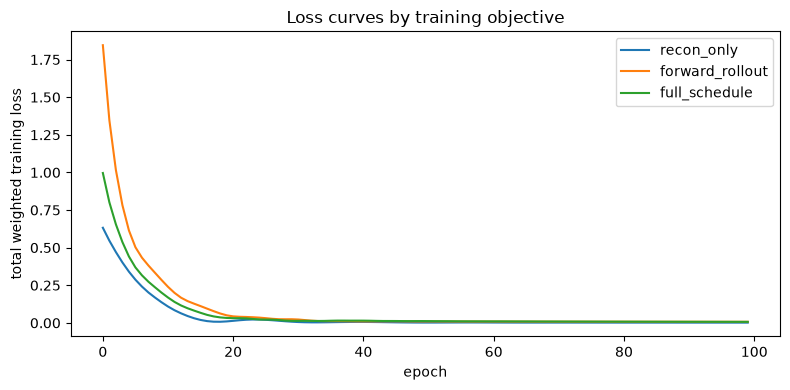

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
for name, loss_history in histories.items():
    ax.plot(loss_history, label=name, linewidth=1.5)
ax.set_xlabel("epoch")
ax.set_ylabel("total weighted training loss")
ax.set_title("Loss curves by training objective")
ax.legend()
fig.tight_layout()
plt.show()


## Evaluate: one-step vs rollout error

Same-sequence metrics for each loss variant (not a held-out split). One-step ranking
can flip with seed or epoch budget; the multi-step gap is the claim to check.

**How to read the next figure:** the left panel averages one-step MSE over **all
consecutive pairs** in the sequence. The right panel rolls out from **snapshot 0
only** and plots the **mean MSE over steps** \(1\ldots H\) (not the error at step
\(H\) alone), so a mildly decreasing curve can appear when early steps are harder
than later ones on this decaying synthetic trajectory.


In [5]:
horizons = [1, 3, 6, 10]
labels = list(configs.keys())

one_step = {name: one_step_mse(models[name], data_sequence) for name in labels}
rollout_by_h = {
    h: {name: rollout_mse(models[name], data_sequence, steps=h) for name in labels}
    for h in horizons
}

print("One-step MSE (mean over all consecutive pairs):")
for name in labels:
    print(f"  {name:16s} {one_step[name]:.6f}")

print("\nRollout MSE from snapshot 0, mean over steps 1..H (H=10):")
for name in labels:
    print(f"  {name:16s} {rollout_by_h[10][name]:.6f}")

consistency = [n for n in labels if n != "recon_only"]
if len(consistency) >= 2:
    base = rollout_by_h[10][consistency[0]]
    print("\nConsistency-config rollout deltas vs first consistency config:")
    for name in consistency:
        delta = rollout_by_h[10][name] - base
        print(f"  {name:16s} {rollout_by_h[10][name]:.6f}  (Δ={delta:+.6f})")


One-step MSE (mean over all consecutive pairs):
  recon_only       0.001810
  forward_rollout  0.002349
  full_schedule    0.002075

Rollout MSE from snapshot 0, mean over steps 1..H (H=10):
  recon_only       3.291687
  forward_rollout  0.001687
  full_schedule    0.001489

Consistency-config rollout deltas vs first consistency config:
  forward_rollout  0.001687  (Δ=+0.000000)
  full_schedule    0.001489  (Δ=-0.000198)


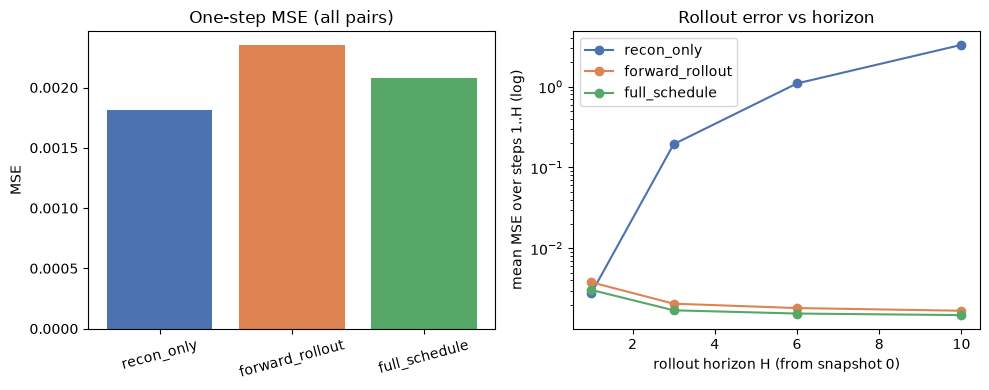

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Shared palette so bar and line colors match per config.
colors = {
    "recon_only": "#4c72b0",
    "forward_rollout": "#dd8452",
    "full_schedule": "#55a868",
}
bar_colors = [colors.get(n, "#8172b3") for n in labels]

axes[0].bar(labels, [one_step[n] for n in labels], color=bar_colors)
axes[0].set_title("One-step MSE (all pairs)")
axes[0].set_ylabel("MSE")
axes[0].tick_params(axis="x", rotation=15)

for name in labels:
    axes[1].plot(
        horizons,
        [rollout_by_h[h][name] for h in horizons],
        marker="o",
        label=name,
        color=colors.get(name, "#8172b3"),
    )
axes[1].set_xlabel("rollout horizon H (from snapshot 0)")
axes[1].set_ylabel("mean MSE over steps 1..H (log)")
axes[1].set_title("Rollout error vs horizon")
axes[1].set_yscale("log")
axes[1].legend()

fig.tight_layout()
plt.show()


## Operator stability options

Beyond loss schedules, KoopmanGraph can constrain the learned operator **K** directly:

- **`koopman_parameterization="odo"`** — orthogonal–diagonal–orthogonal (Cayley)
  factorization with bounded diagonal factors. Discrete ODO is a **soft** mode:
  orthogonal factors imply \(\rho(K)\le\max|d_i|\le\) `koopman_max_spectral_radius`
  via the operator 2-norm, but without a strict \(\varepsilon\)-interior structural
  certificate (prefer `schur` / `dissipative` / `lyapunov` for hard guarantees). Use
  `bound_metric()` for the cheap diagonal-factor bound and `spectral_radius()` for
  the true \(\max|\lambda(K)|\) via eigendecomposition.
- **`LossWeights(..., eigenvalue=...)`** — hinge penalty on eigenvalues outside the
  unit circle.

For **hard** spectral guarantees, see
[`11_long_horizon_stability.ipynb`](11_long_horizon_stability.ipynb).

The snippet below is a **pedagogical blow-up demo**: long-rollout latent norms for an
untrained dense operator whose **K** is manually replaced by a diagonal matrix with
eigenvalues inflated to 1.25, versus an ODO + eigenloss trained model (not a fair
trained dense-vs-ODO bake-off).


In [7]:
torch.manual_seed(MODEL_SEED)
stable_model = GraphKoopmanModel(
    encoder=GNNEncoder(IN_CHANNELS, HIDDEN, LATENT),
    decoder=GNNDecoder(LATENT, HIDDEN, IN_CHANNELS),
    latent_dim=LATENT,
    time_step=0.1,
    koopman_parameterization="odo",
    koopman_max_spectral_radius=0.95,
)
stable_model.fit(
    data_sequence,
    epochs=STABILITY_EPOCHS,
    lr=1e-3,
    loss_weights=LossWeights(reconstruction=1.0, forward=0.5, eigenvalue=0.2),
)

unstable_model = build_model()
with torch.no_grad():
    unstable_eigs = torch.full((LATENT,), 1.25)
    unstable_model.koopman.K.copy_(torch.diag(unstable_eigs))

rollout_steps = 30
stable_norm = latent_rollout_norm(stable_model, data_sequence[0], rollout_steps)
unstable_norm = latent_rollout_norm(unstable_model, data_sequence[0], rollout_steps)
print(f"Latent norm after {rollout_steps} steps")
print(f"  ODO + eigenloss model: {stable_norm:.3f}")
print(f"  Inflated diagonal-K model: {unstable_norm:.3f}")


Latent norm after 30 steps
  ODO + eigenloss model: 1.449
  Inflated diagonal-K model: 5309.002


## Takeaways

- **Reconstruction-only** training is a useful baseline but often underperforms on long rollouts.
- **Forward + rollout** aligns the linear latent map with multi-step `predict` behavior.
- **Backward consistency with a ramp** is an optional stabilizer for bidirectional latent consistency; on this synthetic run **`full_schedule`'s** forward/rollout MSE gain over **`forward_rollout`** is small — tune weights if training becomes noisy, and measure inverse metrics if that is the goal.
- **ODO naming:** `bound_metric()` is the cheap diagonal-factor monitor; `spectral_radius()` is the true spectrum. Soft ODO is not a structural \(\varepsilon\)-interior certificate — see [`11_long_horizon_stability.ipynb`](11_long_horizon_stability.ipynb).

Other `LossWeights` knobs (`lie`, `pde`, `sparsity`, `worst_case`) are covered in
[`14_physics_informed_advection.ipynb`](14_physics_informed_advection.ipynb) and
[`26_sparse_interpretable_operator.ipynb`](26_sparse_interpretable_operator.ipynb).

## Next steps

- [`01_synthetic_graph.ipynb`](01_synthetic_graph.ipynb) — base encode / advance / decode workflow
- [`07_koopman_spectrum.ipynb`](07_koopman_spectrum.ipynb) — eigenvalue diagnostics after training
- [`11_long_horizon_stability.ipynb`](11_long_horizon_stability.ipynb) — hard spectral constraints on long rollouts
- [API reference](https://koopmangraph.readthedocs.io/en/latest/api.html)
